In [28]:
#code in 2D
from random import seed
from random import random
import numpy as np
#import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import numpy as np
from scipy.optimize import curve_fit
def fit_func(x, a, b):
    return a*x + b

import csv

def csv_to_array(file_path):
    data_array = []
    with open(file_path, 'r') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            data_array.append(row)
    data_array=np.array(data_array)
    return data_array

def csv_to_numpy_array(file_path):
    data_array = np.loadtxt(file_path, delimiter=',', dtype=float)
    return data_array

In [29]:
dt=0.000001
gamma=[0.4,0.8,1.2,2.4]

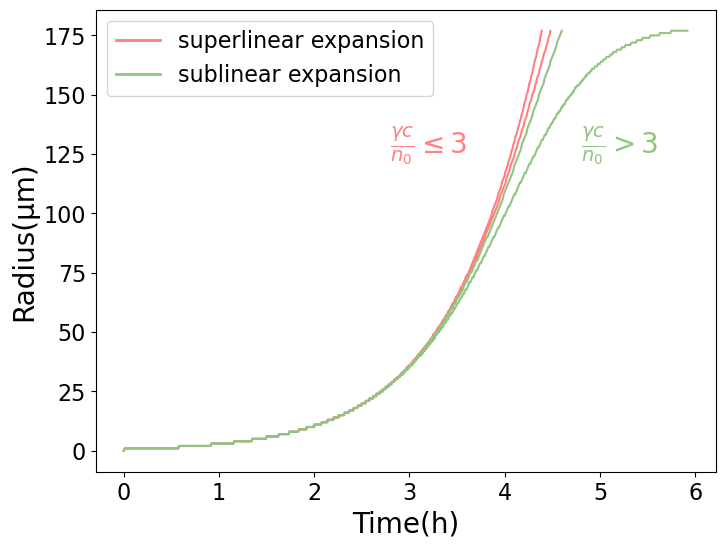

In [27]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [Line2D([0], [0], color=(1.0, 0.5, 0.5, 1.0), lw=2, alpha=1,label='superlinear expansion'),
                   Line2D([0], [0], linestyle='-',color=(0.57, 0.77, 0.5, 1.0),lw=2, alpha=1, label='sublinear expansion')]

# Create the figure
fig, ax = plt.subplots(1,figsize=(8,6))
plt.rcParams.update({'font.size': 20})
ax.legend(handles=legend_elements, loc='upper left',fontsize=16)
i=0
while i <len(gamma):
    xname="rsimutip,inutrientcon=2.4,gamma="+str(gamma[i])+".csv"
    float_array_x = csv_to_numpy_array(xname)
    #xval = csv_to_numpy_array(xname)
    #float_array_x = np.array([float(x) for x in xval])
    aname="slopforedgespeed,inutrientcon=2.4,gamma="+str(gamma[i])+".csv"
    aval = csv_to_numpy_array(aname)
    #float_array_a = np.array([float(a) for a in aval])
    timer=np.linspace(0,len(float_array_x)*dt,len(float_array_x))
    if float(aval)<=0:
        plt.plot(timer[::10000],60*float_array_x[::10000],linestyle='-',color=(0.57, 0.77, 0.5, 1.0))#,label="sublinear expansion")
    else:
        plt.plot(timer[::10000],60*float_array_x[::10000],linestyle='-',color=(1.0, 0.5, 0.5, 1.0))
    i=i+1


plt.text(4.8,125,r"$\frac{\gamma c}{n_{0}}>3$",color=(0.57, 0.77, 0.5, 1.0),fontsize=20)
plt.text(2.8,125,r"$\frac{\gamma c}{n_{0}}\leq3$",color=(1.0, 0.5, 0.5, 1.0),fontsize=20)
ax.tick_params(axis='x', labelsize=16) 
ax.tick_params(axis='y', labelsize=16) 
plt.ylabel("Radius(μm)",fontsize=20)
plt.xlabel("Time(h)",fontsize=20)
#plt.ylim(0,3500)
#plt.xlim(0,30)
#plt.legend(fontsize=15)
plt.savefig("2d_nutrient_radius_over_time_profile_small_l.pdf",bbox_inches = 'tight',dpi=300)
plt.show()